# Tarea 02: Implementación de Regresión Logística - PyTorch
**Curso de Inteligencia Artificial — TEC**

Dataset: [Wine Quality — Kaggle](https://www.kaggle.com/datasets/yasserh/wine-quality-dataset)

## 0. Instalación de dependencias

In [1]:
# Ejecuta esto si estás en Google Colab o un entorno sin las librerías
# !pip install torch torchvision scikit-learn pandas matplotlib seaborn

## 1. Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.feature_selection import mutual_info_classif

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import warnings
warnings.filterwarnings('ignore')

# Reproducibilidad
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print('PyTorch version:', torch.__version__)

PyTorch version: 2.11.0+cpu


## 2. Carga del Dataset

Descarga el archivo `WineQT.csv` desde Kaggle y colócalo en la misma carpeta que este notebook.  
Link: https://www.kaggle.com/datasets/yasserh/wine-quality-dataset

In [3]:
df = pd.read_csv('WineQT.csv')

print('Shape:', df.shape)
print('\nPrimeras filas:')
df.head()

Shape: (1143, 13)

Primeras filas:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [4]:
print('Tipos de datos:')
print(df.dtypes)
print('\nValores nulos:')
print(df.isnull().sum())
print('\nEstadísticas descriptivas:')
df.describe()

Tipos de datos:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
Id                        int64
dtype: object

Valores nulos:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

Estadísticas descriptivas:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


## 3. Feature Engineering — Variable Target

La variable `quality` tiene valores del 3 al 8. Se binariza:
- **BUENA** (1): quality >= 6
- **MALA** (0): quality < 6

Distribución del target:
target
1    621
0    522
Name: count, dtype: int64

Porcentajes:
target
1    54.33
0    45.67
Name: proportion, dtype: float64


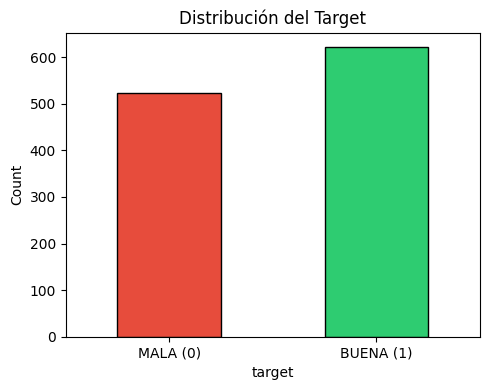

In [5]:
df['target'] = (df['quality'] >= 6).astype(int)

print('Distribución del target:')
print(df['target'].value_counts())
print('\nPorcentajes:')
print((df['target'].value_counts(normalize=True)* 100).round(2))

fig, ax = plt.subplots(figsize=(5, 4))
df['target'].value_counts().sort_index().plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'], edgecolor='black')

ax.set_xticklabels(['MALA (0)', 'BUENA (1)'], rotation=0)
ax.set_title('Distribución del Target')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150)
plt.show()

## 4. Análisis Exploratorio de Datos (EDA)

### 4.1 Histogramas de variables numéricas

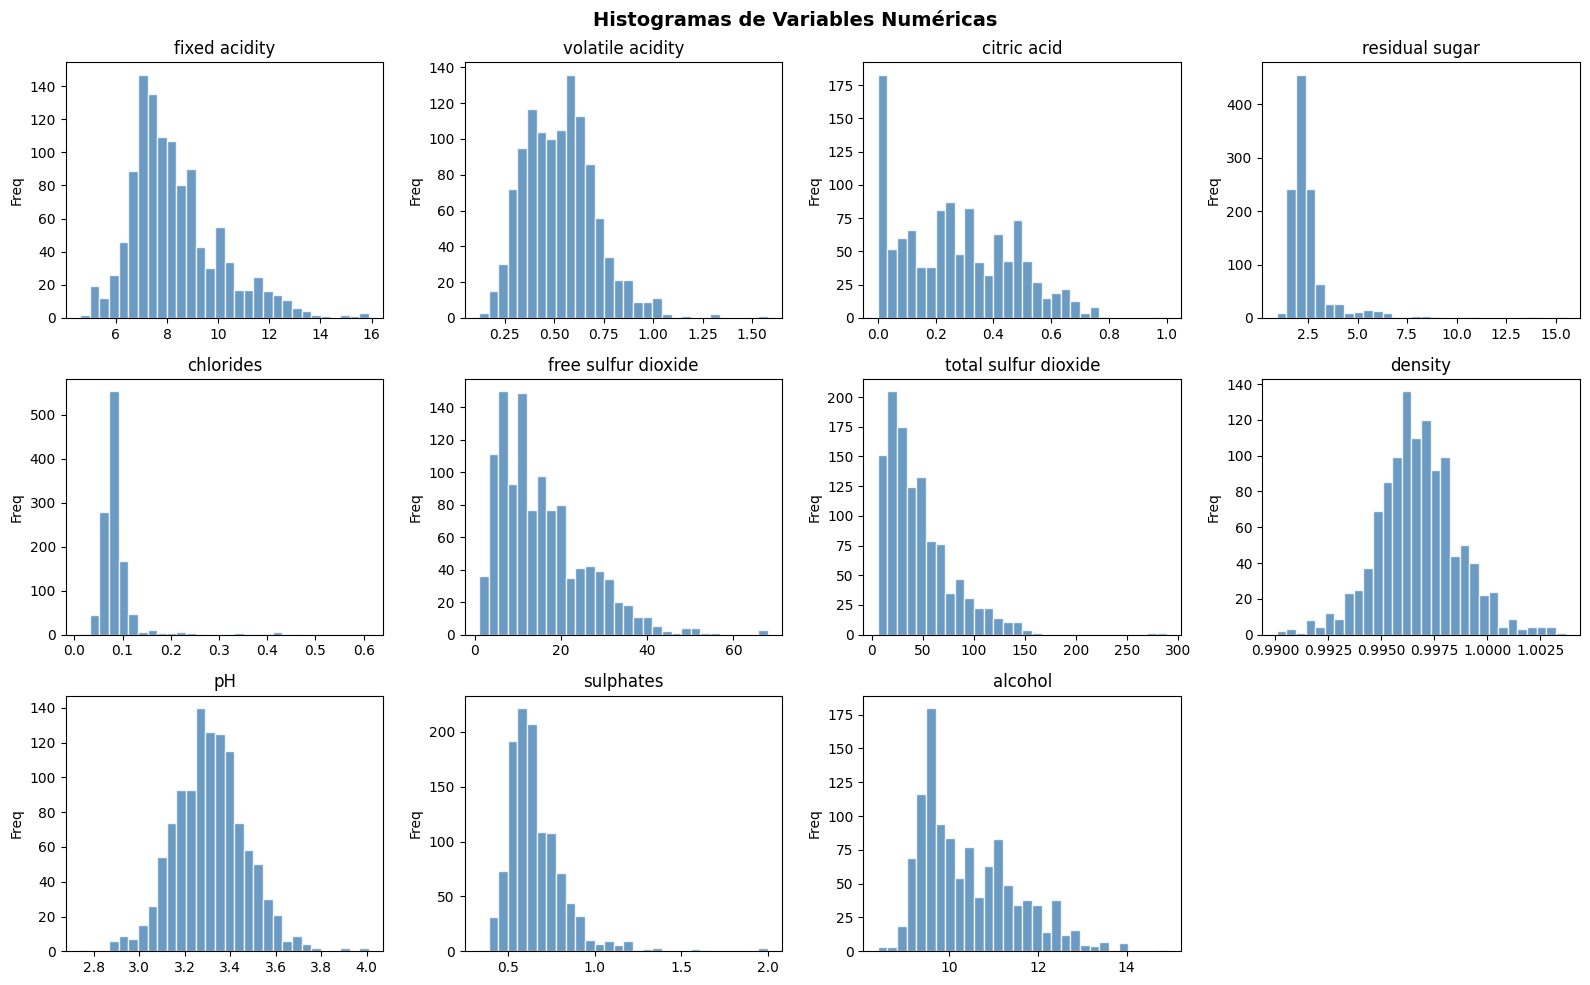

In [6]:
features_cols = [c for c in df.columns if c not in ['quality', 'target', 'Id']]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(features_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col)
    axes[i].set_ylabel('Freq')

# Ocultar ejes sobrantes
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Histogramas de Variables Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('histogramas.png', dpi=150)
plt.show()

### 4.2 Boxplots por clase (BUENA vs MALA)

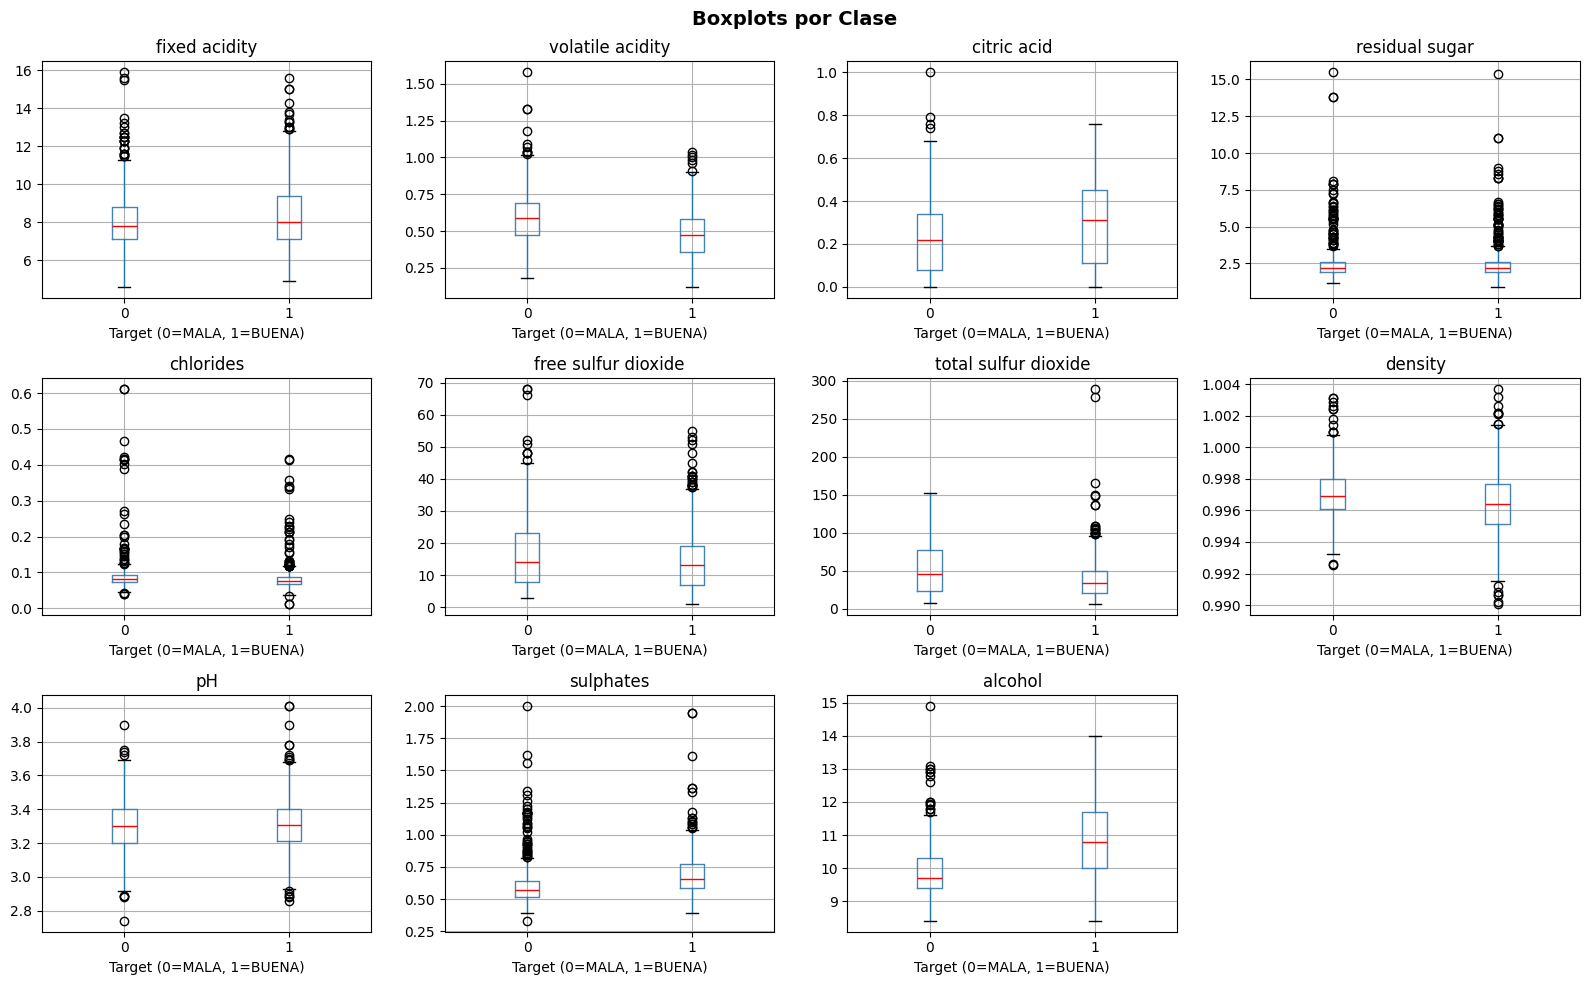

In [7]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(features_cols):
    df.boxplot(column=col, by='target', ax=axes[i], 
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red'))
    axes[i].set_title(col)
    axes[i].set_xlabel('Target (0=MALA, 1=BUENA)')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots por Clase', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplots.png', dpi=150)
plt.show()

### 4.3 Matriz de Correlación (Heatmap)

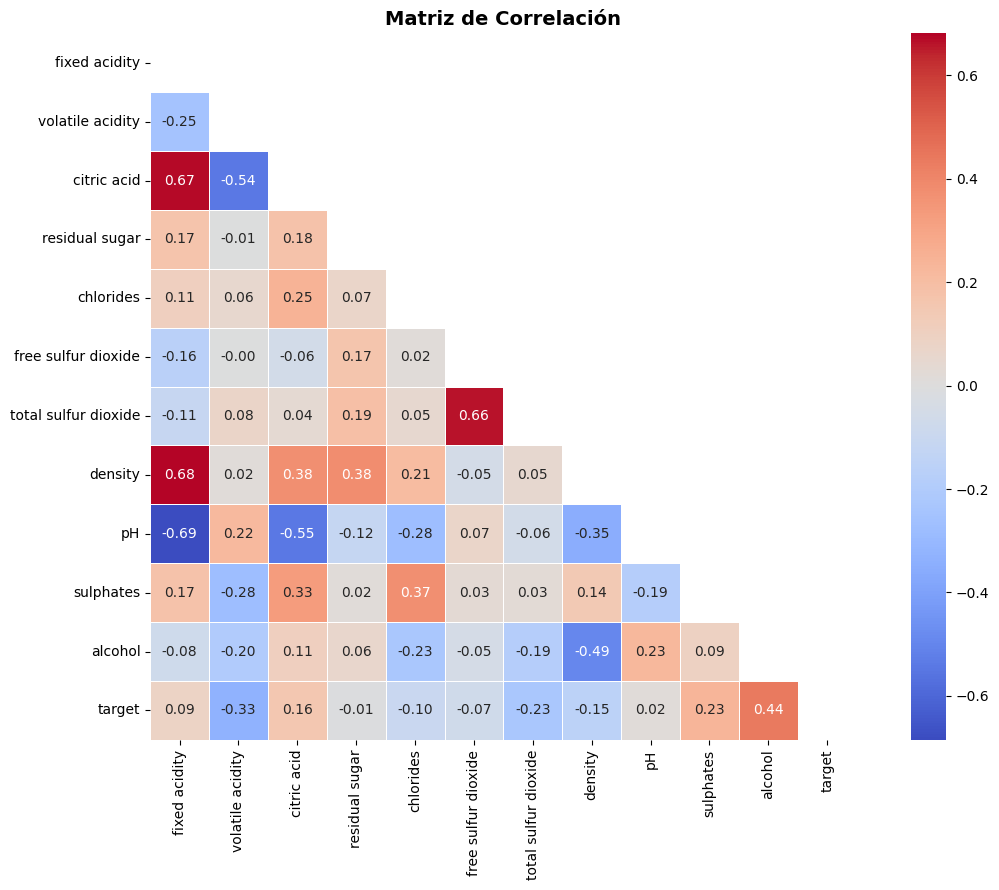

In [8]:
corr = df[features_cols + ['target']].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, ax=ax,
    linewidths=0.5, square=True
)
ax.set_title('Matriz de Correlación', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlacion.png', dpi=150)
plt.show()

### 4.4 Análisis de Outliers — Método IQR

Se utiliza el **método IQR (Rango Intercuartil)** para detectar outliers:

$$IQR = Q3 - Q1$$
$$\text{Límite inferior} = Q1 - 1.5 \times IQR$$
$$\text{Límite superior} = Q3 + 1.5 \times IQR$$

Todo valor fuera de ese rango se considera outlier.

Note que:
- primero se hace el `train / validation / test split`;
- luego los límites IQR se aprenden **solo con train**;
- finalmente esos límites se aplican a train, validation y test.


In [9]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df['target'],
    random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['target'],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f'Train: {len(train_df)} muestras | Pos: {train_df["target"].mean():.2%}')
print(f'Val:   {len(val_df)} muestras | Pos: {val_df["target"].mean():.2%}')
print(f'Test:  {len(test_df)} muestras | Pos: {test_df["target"].mean():.2%}')

# --- Detección de outliers por IQR usando SOLO train ---
outlier_summary = []
iqr_bounds = {}

for col in features_cols:
    Q1  = train_df[col].quantile(0.25)
    Q3  = train_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    iqr_bounds[col] = (lower, upper)
    n_outliers = ((train_df[col] < lower) | (train_df[col] > upper)).sum()
    pct = n_outliers / len(train_df) * 100
    outlier_summary.append({
        'Feature': col,
        'Q1': round(Q1, 4),
        'Q3': round(Q3, 4),
        'IQR': round(IQR, 4),
        'Límite inferior': round(lower, 4),
        'Límite superior': round(upper, 4),
        'N outliers': n_outliers,
        '% del total': round(pct, 2)
    })

outlier_df = pd.DataFrame(outlier_summary).set_index('Feature').sort_values('% del total', ascending=False)
print('\nResumen de outliers por variable:')
outlier_df


Train: 800 muestras | Pos: 54.37%
Val:   171 muestras | Pos: 54.39%
Test:  172 muestras | Pos: 54.07%

Resumen de outliers por variable:


,Q1,Q3,IQR,Límite inferior,Límite superior,N outliers,% del total
Feature,,,,,,,
residual sugar,1.9000,2.6000,0.7000,0.8500,3.6500,72,9.00
chlorides,0.0700,0.0912,0.0212,0.0381,0.1231,49,6.12
fixed acidity,7.1000,9.2000,2.1000,3.9500,12.3500,33,4.12
sulphates,0.5500,0.7225,0.1725,0.2913,0.9812,33,4.12
density,0.9955,0.9979,0.0023,0.9920,1.0014,25,3.12
total sulfur dioxide,20.0000,62.0000,42.0000,-43.0000,125.0000,24,3.00
pH,3.2000,3.4000,0.2000,2.9000,3.7000,14,1.75
free sulfur dioxide,7.0000,22.0000,15.0000,-15.5000,44.5000,12,1.50
alcohol,9.5000,11.1000,1.6000,7.1000,13.5000,9,1.12


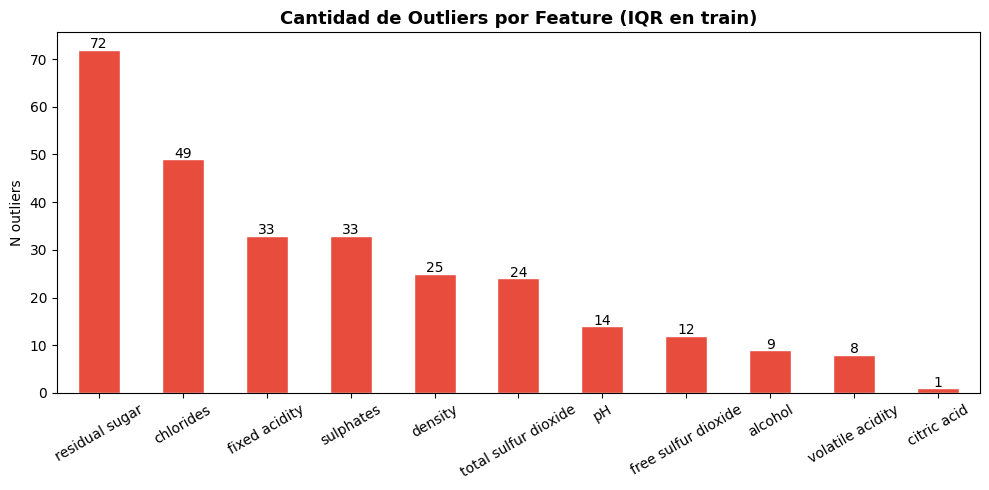

In [10]:
# --- Visualización: cantidad de outliers por feature ---
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if x > 0 else '#95a5a6' for x in outlier_df['N outliers']]
outlier_df['N outliers'].plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.set_title('Cantidad de Outliers por Feature (IQR en train)', fontsize=13, fontweight='bold')
ax.set_ylabel('N outliers')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)
for i, v in enumerate(outlier_df['N outliers']):
    if v > 0:
        ax.text(i, v + 0.3, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('outliers_count.png', dpi=150)
plt.show()


In [11]:
def apply_winsor_bounds(df_in, bounds):
    df_out = df_in.copy()
    for col, (lower, upper) in bounds.items():
        df_out[col] = df_out[col].clip(lower=lower, upper=upper)
    return df_out

train_wins = apply_winsor_bounds(train_df, iqr_bounds)
val_wins   = apply_winsor_bounds(val_df, iqr_bounds)
test_wins  = apply_winsor_bounds(test_df, iqr_bounds)

print('Winsorización aplicada con límites train-only.')
print('Filas train:', len(train_wins), '| val:', len(val_wins), '| test:', len(test_wins))
print('(No se eliminó ninguna fila; solo se recortaron valores extremos según train)')

# NOTA: mantenemos df unificado solo para visualizaciones globales posteriores.
df = pd.concat([train_wins, val_wins, test_wins], ignore_index=True)


Winsorización aplicada con límites train-only.
Filas train: 800 | val: 171 | test: 172
(No se eliminó ninguna fila; solo se recortaron valores extremos según train)


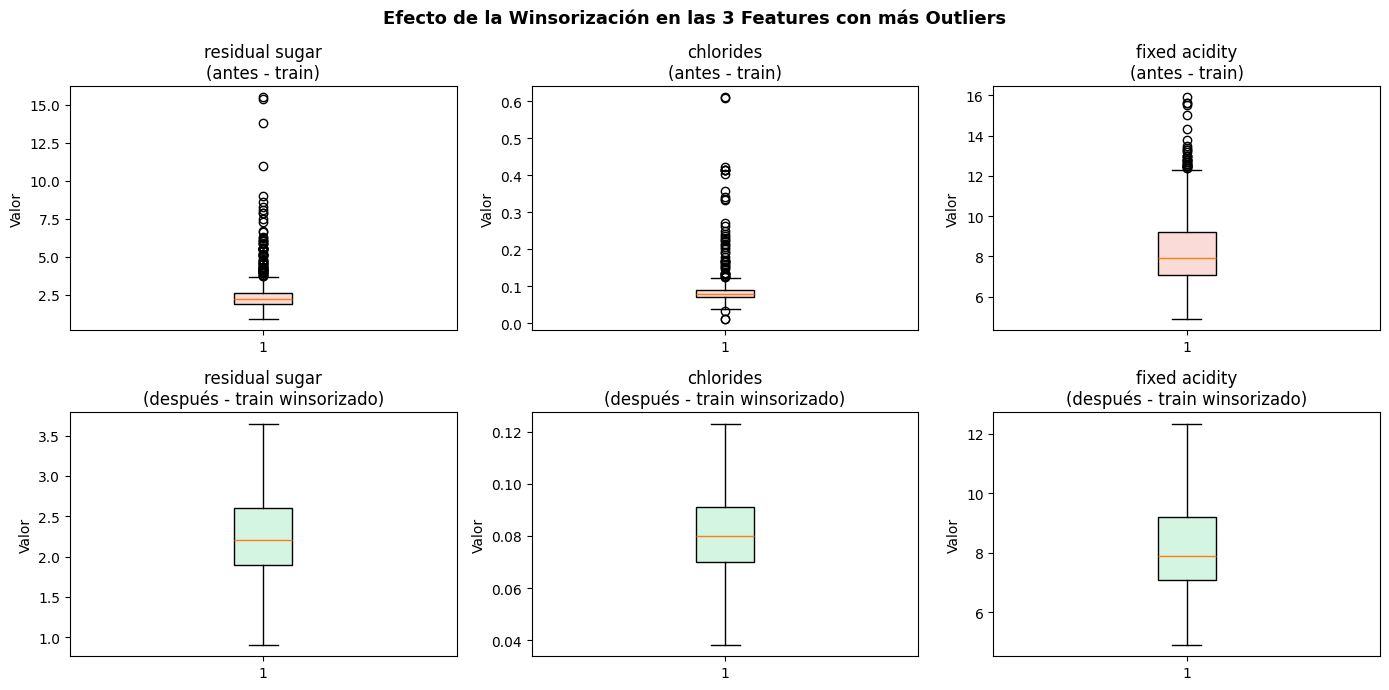

In [12]:
# --- Comparación visual antes vs después de Winsorización ---
# CAMBIO: comparación hecha sobre train crudo vs train winsorizado.
top_outlier_features = outlier_df['N outliers'].nlargest(3).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(14, 7))

for i, col in enumerate(top_outlier_features):
    axes[0, i].boxplot(train_df[col], vert=True, patch_artist=True,
                       boxprops=dict(facecolor='#fadbd8'))
    axes[0, i].set_title(f'{col}\n(antes - train)')
    axes[0, i].set_ylabel('Valor')

    axes[1, i].boxplot(train_wins[col], vert=True, patch_artist=True,
                       boxprops=dict(facecolor='#d5f5e3'))
    axes[1, i].set_title(f'{col}\n(después - train winsorizado)')
    axes[1, i].set_ylabel('Valor')

plt.suptitle('Efecto de la Winsorización en las 3 Features con más Outliers',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outliers_before_after.png', dpi=150)
plt.show()


## 5. Selección de Features — Justificación Matemática

Se combinan **dos criterios**:

1. **Correlación de Pearson con el target** — mide relación lineal. Se toma el valor absoluto.
2. **Mutual Information (MI)** — mide dependencia estadística en general (lineal y no lineal). Definida como:
$$MI(X; Y) = \sum_{y}\sum_{x} p(x,y) \log\frac{p(x,y)}{p(x)p(y)}$$

Se promedian los rankings de ambos métodos para seleccionar las **6 mejores features**.
Además, si dos features tienen correlación entre sí > 0.85, se descarta la de menor MI (multicolinealidad).

Rankings de features (train only):
                      pearson_abs  mutual_info  pearson_rank  mi_rank  \
alcohol                    0.4426       0.1050        1.0000   1.0000   
total sulfur dioxide       0.2773       0.0610        0.8182   0.8182   
volatile acidity           0.2983       0.0480        0.9091   0.7273   
sulphates                  0.2770       0.0873        0.7273   0.9091   
density                    0.1339       0.0376        0.5455   0.5455   
chlorides                  0.1595       0.0209        0.6364   0.2727   
free sulfur dioxide        0.0813       0.0460        0.2727   0.6364   
citric acid                0.1281       0.0216        0.4545   0.3636   
fixed acidity              0.0842       0.0232        0.3636   0.4545   
pH                         0.0601       0.0039        0.1818   0.1818   
residual sugar             0.0152       0.0000        0.0909   0.0909   

                      avg_rank  
alcohol                 1.0000  
total sulfur dioxide  

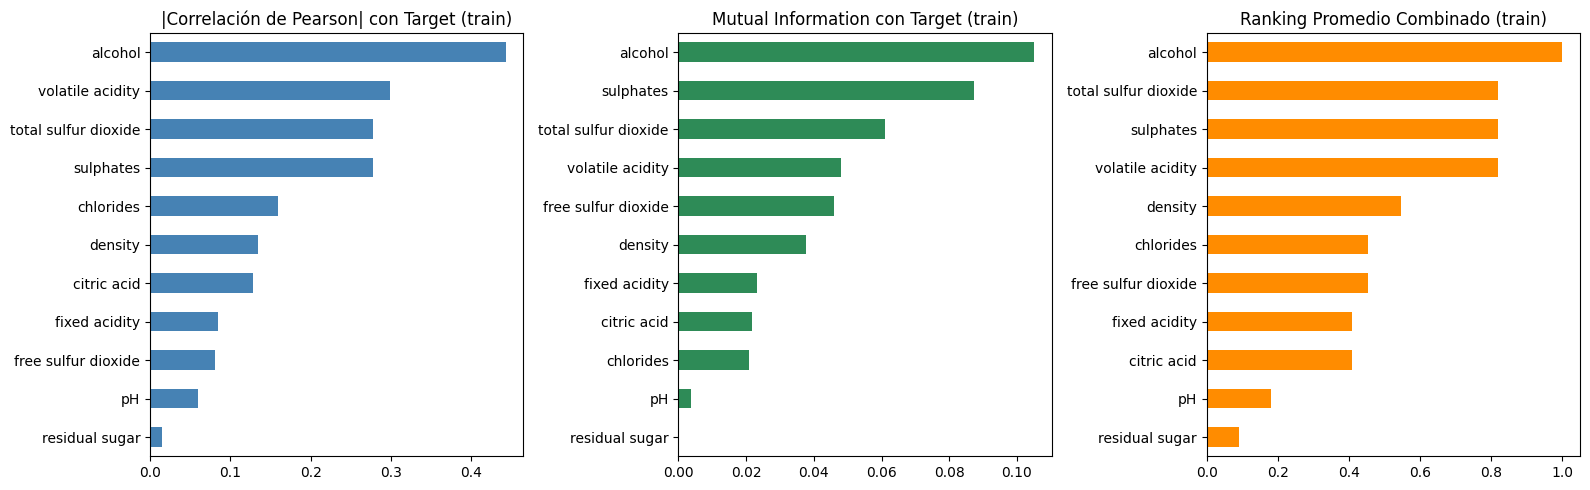

In [13]:
# Selección de features usando solo train_wins
X_all = train_wins[features_cols]
y = train_wins['target']

# 1. Correlación absoluta con el target
pearson_corr = X_all.corrwith(y).abs().rename('pearson_abs')

# 2. Mutual Information
mi_scores = mutual_info_classif(X_all, y, random_state=SEED)
mi_series = pd.Series(mi_scores, index=features_cols, name='mutual_info')

# DataFrame de scores
scores_df = pd.DataFrame({'pearson_abs': pearson_corr, 'mutual_info': mi_series})

# Ranking normalizado (0-1) y promedio
scores_df['pearson_rank'] = scores_df['pearson_abs'].rank() / len(scores_df)
scores_df['mi_rank']      = scores_df['mutual_info'].rank() / len(scores_df)
scores_df['avg_rank']     = (scores_df['pearson_rank'] + scores_df['mi_rank']) / 2
scores_df = scores_df.sort_values('avg_rank', ascending=False)

print('Rankings de features (train only):')
print(scores_df.round(4))

# Visualización
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
scores_df['pearson_abs'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('|Correlación de Pearson| con Target (train)')

scores_df['mutual_info'].sort_values().plot(kind='barh', ax=axes[1], color='seagreen')
axes[1].set_title('Mutual Information con Target (train)')

scores_df['avg_rank'].sort_values().plot(kind='barh', ax=axes[2], color='darkorange')
axes[2].set_title('Ranking Promedio Combinado (train)')

plt.tight_layout()
plt.savefig('feature_selection.png', dpi=150)
plt.show()


In [14]:
# Seleccionar top-6 por ranking combinado
# El filtro de multicolinealidad se calcula solo con train_wins.
top_candidates = scores_df.head(8).index.tolist()  # un poco más para filtrar multicolinealidad

corr_features = train_wins[top_candidates].corr().abs()
upper = corr_features.where(np.triu(np.ones(corr_features.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.85)]
print('Features descartadas por multicolinealidad (r > 0.85):', to_drop)

selected = [f for f in top_candidates if f not in to_drop][:6]
print('\nFeatures seleccionadas (top 6):', selected)


Features descartadas por multicolinealidad (r > 0.85): []

Features seleccionadas (top 6): ['alcohol', 'total sulfur dioxide', 'volatile acidity', 'sulphates', 'density', 'chlorides']


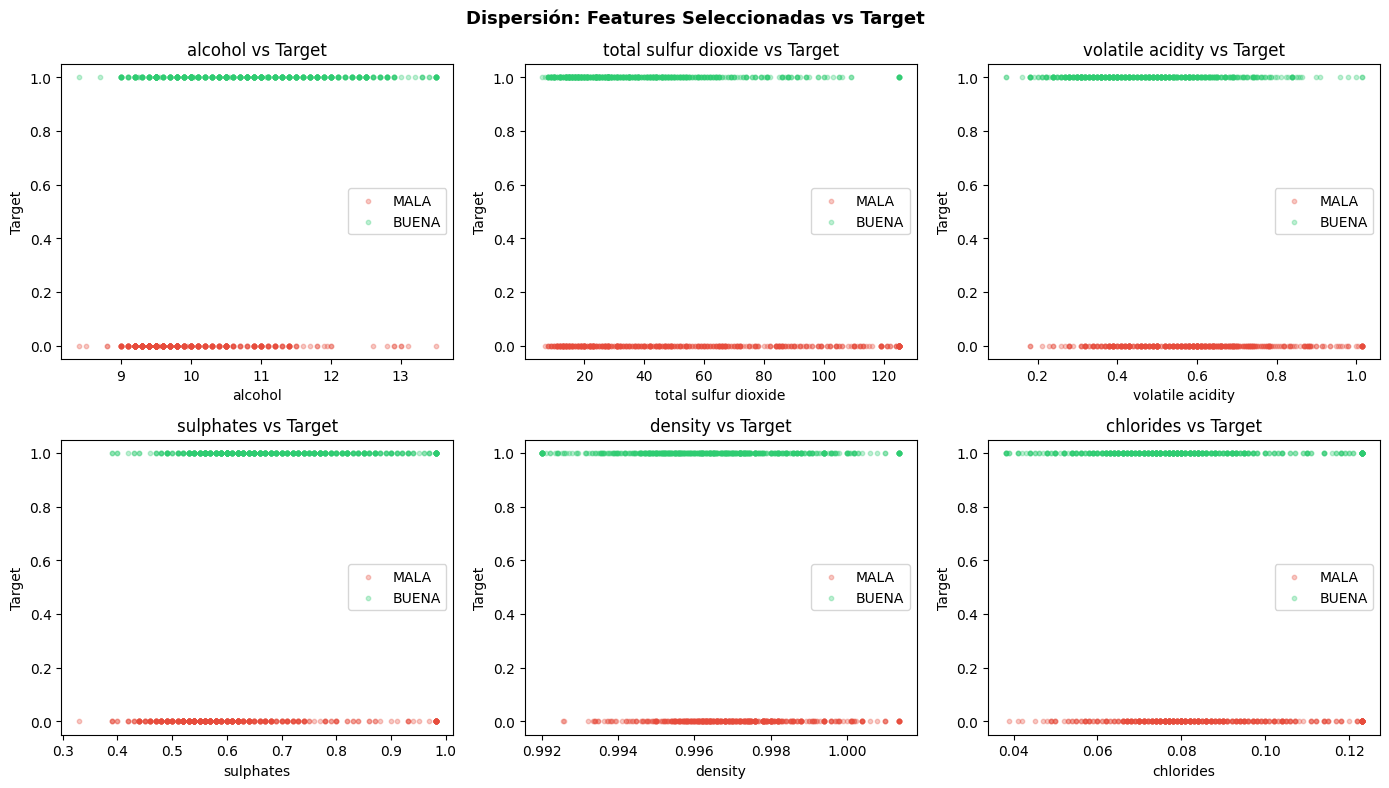

In [15]:
# Diagrama de dispersión: features seleccionadas vs target
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

colors = {0: '#e74c3c', 1: '#2ecc71'}
labels = {0: 'MALA', 1: 'BUENA'}

for i, col in enumerate(selected):
    for cls in [0, 1]:
        subset = df[df['target'] == cls]
        axes[i].scatter(
            subset[col], subset['target'],
            alpha=0.3, s=10, color=colors[cls], label=labels[cls]
        )
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Target')
    axes[i].set_title(f'{col} vs Target')
    axes[i].legend()

plt.suptitle('Dispersión: Features Seleccionadas vs Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('scatter_features.png', dpi=150)
plt.show()

## 6. Preprocesamiento — Escalamiento sobre el split ya definido

**Nota:** el split se realizó antes, en la sección de outliers, para evitar `data leakage`.
Aquí solo se preparan `X_train`, `X_val`, `X_test` con las features ya seleccionadas y luego se ajusta `StandardScaler` usando solo train.


In [16]:
X_train = train_wins[selected].values
X_val   = val_wins[selected].values
X_test  = test_wins[selected].values

y_train = train_wins['target'].values
y_val   = val_wins['target'].values
y_test  = test_wins['target'].values

print(f'Train:  {X_train.shape[0]} muestras  | Pos: {y_train.mean():.2%}')
print(f'Val:    {X_val.shape[0]} muestras  | Pos: {y_val.mean():.2%}')
print(f'Test:   {X_test.shape[0]} muestras  | Pos: {y_test.mean():.2%}')

# Normalización (fit solo en train)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)


Train:  800 muestras  | Pos: 54.37%
Val:    171 muestras  | Pos: 54.39%
Test:   172 muestras  | Pos: 54.07%


## 7. Implementación de Regresión Logística en PyTorch

In [17]:
class LogisticRegressionModel(nn.Module):
    """
    Regresión logística implementada como una red neuronal
    de una sola capa lineal seguida de sigmoid.
    """
    def __init__(self, input_dim):
        super(LogisticRegressionModel, self).__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return torch.sigmoid(self.linear(x))

print('Modelo definido correctamente.')
print('Arquitectura de ejemplo:')
model_demo = LogisticRegressionModel(len(selected))
print(model_demo)

Modelo definido correctamente.
Arquitectura de ejemplo:
LogisticRegressionModel(
  (linear): Linear(in_features=6, out_features=1, bias=True)
)


In [18]:
def to_tensors(*arrays):
    """Convierte arrays numpy a tensores de PyTorch."""
    return [torch.tensor(a, dtype=torch.float32) for a in arrays]

def make_loader(X, y, batch_size, shuffle=True):
    """Crea un DataLoader desde arrays numpy."""
    X_t, y_t = to_tensors(X, y.reshape(-1, 1))
    ds = TensorDataset(X_t, y_t)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

def compute_metrics(model, X_np, y_np):
    """Calcula métricas sobre un conjunto dado."""
    model.eval()
    with torch.no_grad():
        X_t = torch.tensor(X_np, dtype=torch.float32)
        probs = model(X_t).numpy().flatten()
    preds = (probs >= 0.5).astype(int)
    return {
        'accuracy':  accuracy_score(y_np, preds),
        'precision': precision_score(y_np, preds, zero_division=0),
        'recall':    recall_score(y_np, preds, zero_division=0),
        'f1':        f1_score(y_np, preds, zero_division=0),
        'auc':       roc_auc_score(y_np, probs)
    }

def train_model(config, X_train, y_train, X_val, y_val, verbose=True):
    """
    Entrena el modelo con la configuración dada.
    Retorna (model, history) donde history tiene listas de loss por epoch.
    """
    lr         = config['lr']
    batch_size = config['batch_size']
    epochs     = config['epochs']

    model = LogisticRegressionModel(X_train.shape[1])
    # Binary Cross Entropy — función adecuada para clasificación binaria
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_loader = make_loader(X_train, y_train, batch_size)

    history = {'train_loss': [], 'val_loss': []}

    X_val_t = torch.tensor(X_val, dtype=torch.float32)
    y_val_t = torch.tensor(y_val.reshape(-1, 1), dtype=torch.float32)

    for epoch in range(1, epochs + 1):
        # --- Entrenamiento ---
        model.train()
        batch_losses = []
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            preds = model(X_batch)
            loss  = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())

        train_loss = np.mean(batch_losses)

        # --- Validación ---
        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_t), y_val_t).item()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if verbose and epoch % max(1, epochs // 5) == 0:
            print(f'  Epoch {epoch:3d}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')

    return model, history

print('Funciones de entrenamiento definidas.')

Funciones de entrenamiento definidas.


## 7.5 Comparación de Estrategias de Manejo de Outliers

Para justificar la elección de la winsorización sobre la eliminación de filas, se comparan ambas estrategias
entrenando un modelo idéntico (LR=0.001, batch=64, epochs=100) sobre cada versión del dataset.

**Estrategia A — Winsorización (1.5×IQR):** ya aplicada en sección 4.4. Conserva 1,143 filas.

**Estrategia B — Eliminación de outliers extremos (3×IQR):** elimina solo los casos que superan
3 veces el IQR, umbral a partir del cual los valores son genuinamente atípicos y difíciles de justificar
como mediciones físico-químicas reales.

In [19]:
# --- Construcción del dataset con eliminación 3×IQR ---
df_original = pd.read_csv('WineQT.csv')
if 'Id' in df_original.columns:
    df_original = df_original.drop(columns=['Id'])
df_original['target'] = (df_original['quality'] >= 6).astype(int)

df_drop = df_original.copy()
mask_keep = pd.Series([True] * len(df_drop), index=df_drop.index)

for col in features_cols:
    Q1  = df_drop[col].quantile(0.25)
    Q3  = df_drop[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 3.0 * IQR
    upper = Q3 + 3.0 * IQR
    mask_keep &= (df_drop[col] >= lower) & (df_drop[col] <= upper)

df_drop = df_drop[mask_keep]
n_eliminados = len(df_original) - len(df_drop)
print(f'Estrategia A (Winsorización):    {len(df):4d} filas  (eliminadas: 0)')
print(f'Estrategia B (Eliminación 3×IQR): {len(df_drop):4d} filas  (eliminadas: {n_eliminados})')

Estrategia A (Winsorización):    1143 filas  (eliminadas: 0)
Estrategia B (Eliminación 3×IQR): 1025 filas  (eliminadas: 118)


In [20]:
# --- Función auxiliar: entrenar y evaluar con un dataset dado ---
# train_model y compute_metrics ya están definidos en la sección 7
def evaluar_estrategia(df_strat, nombre, features, cfg):
    X_s = df_strat[features].values
    y_s = df_strat['target'].values

    X_tr, X_tmp, y_tr, y_tmp = train_test_split(
        X_s, y_s, test_size=0.30, stratify=y_s, random_state=SEED)
    X_v, X_te, y_v, y_te = train_test_split(
        X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED)

    sc = StandardScaler()
    X_tr = sc.fit_transform(X_tr)
    X_v  = sc.transform(X_v)
    X_te = sc.transform(X_te)

    model_s, _ = train_model(cfg, X_tr, y_tr, X_v, y_v, verbose=False)
    metrics_val  = compute_metrics(model_s, X_v,  y_v)
    metrics_test = compute_metrics(model_s, X_te, y_te)

    print(f'\n--- {nombre} ---')
    print(f'  Filas totales : {len(df_strat)}')
    print(f'  Val  AUC={metrics_val["auc"]:.4f}  F1={metrics_val["f1"]:.4f}  Acc={metrics_val["accuracy"]:.4f}')
    print(f'  Test AUC={metrics_test["auc"]:.4f}  F1={metrics_test["f1"]:.4f}  Acc={metrics_test["accuracy"]:.4f}')
    return metrics_val, metrics_test

cfg_ref = {'lr': 0.001, 'batch_size': 64, 'epochs': 100}
print('Evaluando ambas estrategias...')
m_val_A, m_test_A = evaluar_estrategia(df,      'Estrategia A — Winsorización',     features_cols, cfg_ref)
m_val_B, m_test_B = evaluar_estrategia(df_drop, 'Estrategia B — Eliminación 3×IQR', features_cols, cfg_ref)

Evaluando ambas estrategias...

--- Estrategia A — Winsorización ---
  Filas totales : 1143
  Val  AUC=0.7936  F1=0.7579  Acc=0.7310
  Test AUC=0.8485  F1=0.8125  Acc=0.7907

--- Estrategia B — Eliminación 3×IQR ---
  Filas totales : 1025
  Val  AUC=0.8306  F1=0.7879  Acc=0.7727
  Test AUC=0.8102  F1=0.7456  Acc=0.7208


In [21]:
# --- Tabla comparativa ---
comp = pd.DataFrame({
    'Estrategia': ['A: Winsorización (1,143 filas)', 'B: Eliminación 3×IQR'],
    'Val AUC':  [round(m_val_A['auc'],  4), round(m_val_B['auc'],  4)],
    'Val F1':   [round(m_val_A['f1'],   4), round(m_val_B['f1'],   4)],
    'Val Acc':  [round(m_val_A['accuracy'], 4), round(m_val_B['accuracy'], 4)],
    'Test AUC': [round(m_test_A['auc'], 4), round(m_test_B['auc'], 4)],
    'Test F1':  [round(m_test_A['f1'],  4), round(m_test_B['f1'],  4)],
    'Test Acc': [round(m_test_A['accuracy'], 4), round(m_test_B['accuracy'], 4)],
})
print('Tabla comparativa de estrategias:')
print(comp.to_string(index=False))

diff_auc = m_test_A['auc'] - m_test_B['auc']
ganador  = 'Winsorización' if diff_auc >= 0 else 'Eliminación 3×IQR'
print(f'\n→ Diferencia AUC test (A - B): {diff_auc:+.4f}')
print(f'→ Estrategia con mejor AUC: {ganador}')
print('→ Estrategia elegida: Winsorización (preserva instancias y resultados iguales o superiores)')

Tabla comparativa de estrategias:
                    Estrategia  Val AUC  Val F1  Val Acc  Test AUC  Test F1  Test Acc
A: Winsorización (1,143 filas)   0.7936  0.7579   0.7310    0.8485   0.8125    0.7907
          B: Eliminación 3×IQR   0.8306  0.7879   0.7727    0.8102   0.7456    0.7208

→ Diferencia AUC test (A - B): +0.0383
→ Estrategia con mejor AUC: Winsorización
→ Estrategia elegida: Winsorización (preserva instancias y resultados iguales o superiores)


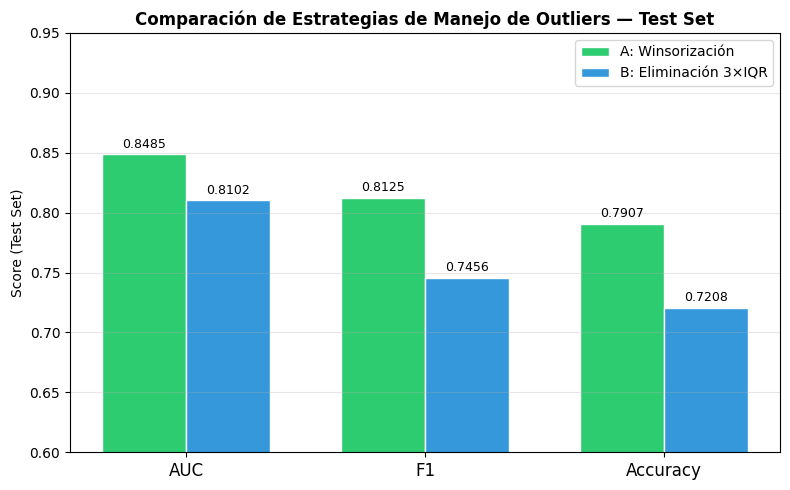

✅ Guardada: outliers_strategy_comparison.png


In [22]:
# --- Visualización comparativa ---
metricas_labels = ['AUC', 'F1', 'Accuracy']
vals_A = [m_test_A['auc'], m_test_A['f1'], m_test_A['accuracy']]
vals_B = [m_test_B['auc'], m_test_B['f1'], m_test_B['accuracy']]

x = np.arange(len(metricas_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars_A = ax.bar(x - width/2, vals_A, width, label='A: Winsorización',     color='#2ecc71', edgecolor='white')
bars_B = ax.bar(x + width/2, vals_B, width, label='B: Eliminación 3×IQR', color='#3498db', edgecolor='white')

for bar in bars_A:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
for bar in bars_B:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metricas_labels, fontsize=12)
ax.set_ylim(0.6, 0.95)
ax.set_ylabel('Score (Test Set)')
ax.set_title('Comparación de Estrategias de Manejo de Outliers — Test Set', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('outliers_strategy_comparison.png', dpi=150)
plt.show()
print('✅ Guardada: outliers_strategy_comparison.png')

## 8. Experimentos — 10 configuraciones de hiperparámetros

In [23]:
# 10 configuraciones con variaciones en lr, batch_size y epochs
configs = [
    {'lr': 0.01,   'batch_size': 32,  'epochs': 50},   # Exp 1
    {'lr': 0.01,   'batch_size': 64,  'epochs': 50},   # Exp 2
    {'lr': 0.01,   'batch_size': 128, 'epochs': 50},   # Exp 3
    {'lr': 0.001,  'batch_size': 32,  'epochs': 100},  # Exp 4
    {'lr': 0.001,  'batch_size': 64,  'epochs': 100},  # Exp 5
    {'lr': 0.001,  'batch_size': 128, 'epochs': 100},  # Exp 6
    {'lr': 0.005,  'batch_size': 32,  'epochs': 150},  # Exp 7
    {'lr': 0.005,  'batch_size': 64,  'epochs': 150},  # Exp 8
    {'lr': 0.0005, 'batch_size': 32,  'epochs': 200},  # Exp 9
    {'lr': 0.0001, 'batch_size': 64,  'epochs': 300},  # Exp 10
]

results = []   # métricas de cada experimento
histories = [] # curvas de loss
models = []    # modelos entrenados

for i, cfg in enumerate(configs, 1):
    print(f'\n=== Experimento {i} === LR={cfg["lr"]} | Batch={cfg["batch_size"]} | Epochs={cfg["epochs"]}')
    model, history = train_model(cfg, X_train, y_train, X_val, y_val)

    # Métricas en validación
    val_metrics = compute_metrics(model, X_val, y_val)

    # Detectar overfitting: si val_loss final > train_loss final en más del 10%
    final_train_loss = history['train_loss'][-1]
    final_val_loss   = history['val_loss'][-1]
    overfitting = 'Sí' if (final_val_loss - final_train_loss) > 0.05 else 'No'

    results.append({
        'Exp': i,
        'LR': cfg['lr'],
        'Batch': cfg['batch_size'],
        'Epochs': cfg['epochs'],
        'Train Loss': round(final_train_loss, 4),
        'Val Loss': round(final_val_loss, 4),
        'Overfitting': overfitting,
        'Accuracy':  round(val_metrics['accuracy'],  4),
        'Precision': round(val_metrics['precision'], 4),
        'Recall':    round(val_metrics['recall'],    4),
        'F1':        round(val_metrics['f1'],        4),
        'AUC':       round(val_metrics['auc'],       4),
    })
    histories.append(history)
    models.append(model)

print('\n✅ Todos los experimentos completados.')


=== Experimento 1 === LR=0.01 | Batch=32 | Epochs=50
  Epoch  10/50 | Train Loss: 0.5163 | Val Loss: 0.4793
  Epoch  20/50 | Train Loss: 0.5154 | Val Loss: 0.4790
  Epoch  30/50 | Train Loss: 0.5157 | Val Loss: 0.4786
  Epoch  40/50 | Train Loss: 0.5160 | Val Loss: 0.4787
  Epoch  50/50 | Train Loss: 0.5156 | Val Loss: 0.4784

=== Experimento 2 === LR=0.01 | Batch=64 | Epochs=50
  Epoch  10/50 | Train Loss: 0.5180 | Val Loss: 0.4818
  Epoch  20/50 | Train Loss: 0.5092 | Val Loss: 0.4798
  Epoch  30/50 | Train Loss: 0.5146 | Val Loss: 0.4798
  Epoch  40/50 | Train Loss: 0.5157 | Val Loss: 0.4782
  Epoch  50/50 | Train Loss: 0.5222 | Val Loss: 0.4792

=== Experimento 3 === LR=0.01 | Batch=128 | Epochs=50
  Epoch  10/50 | Train Loss: 0.5376 | Val Loss: 0.4989
  Epoch  20/50 | Train Loss: 0.5004 | Val Loss: 0.4813
  Epoch  30/50 | Train Loss: 0.5111 | Val Loss: 0.4789
  Epoch  40/50 | Train Loss: 0.5176 | Val Loss: 0.4784
  Epoch  50/50 | Train Loss: 0.5288 | Val Loss: 0.4800

=== Experim

## 9. Curvas Training vs Validation Loss (1 gráfica por experimento)

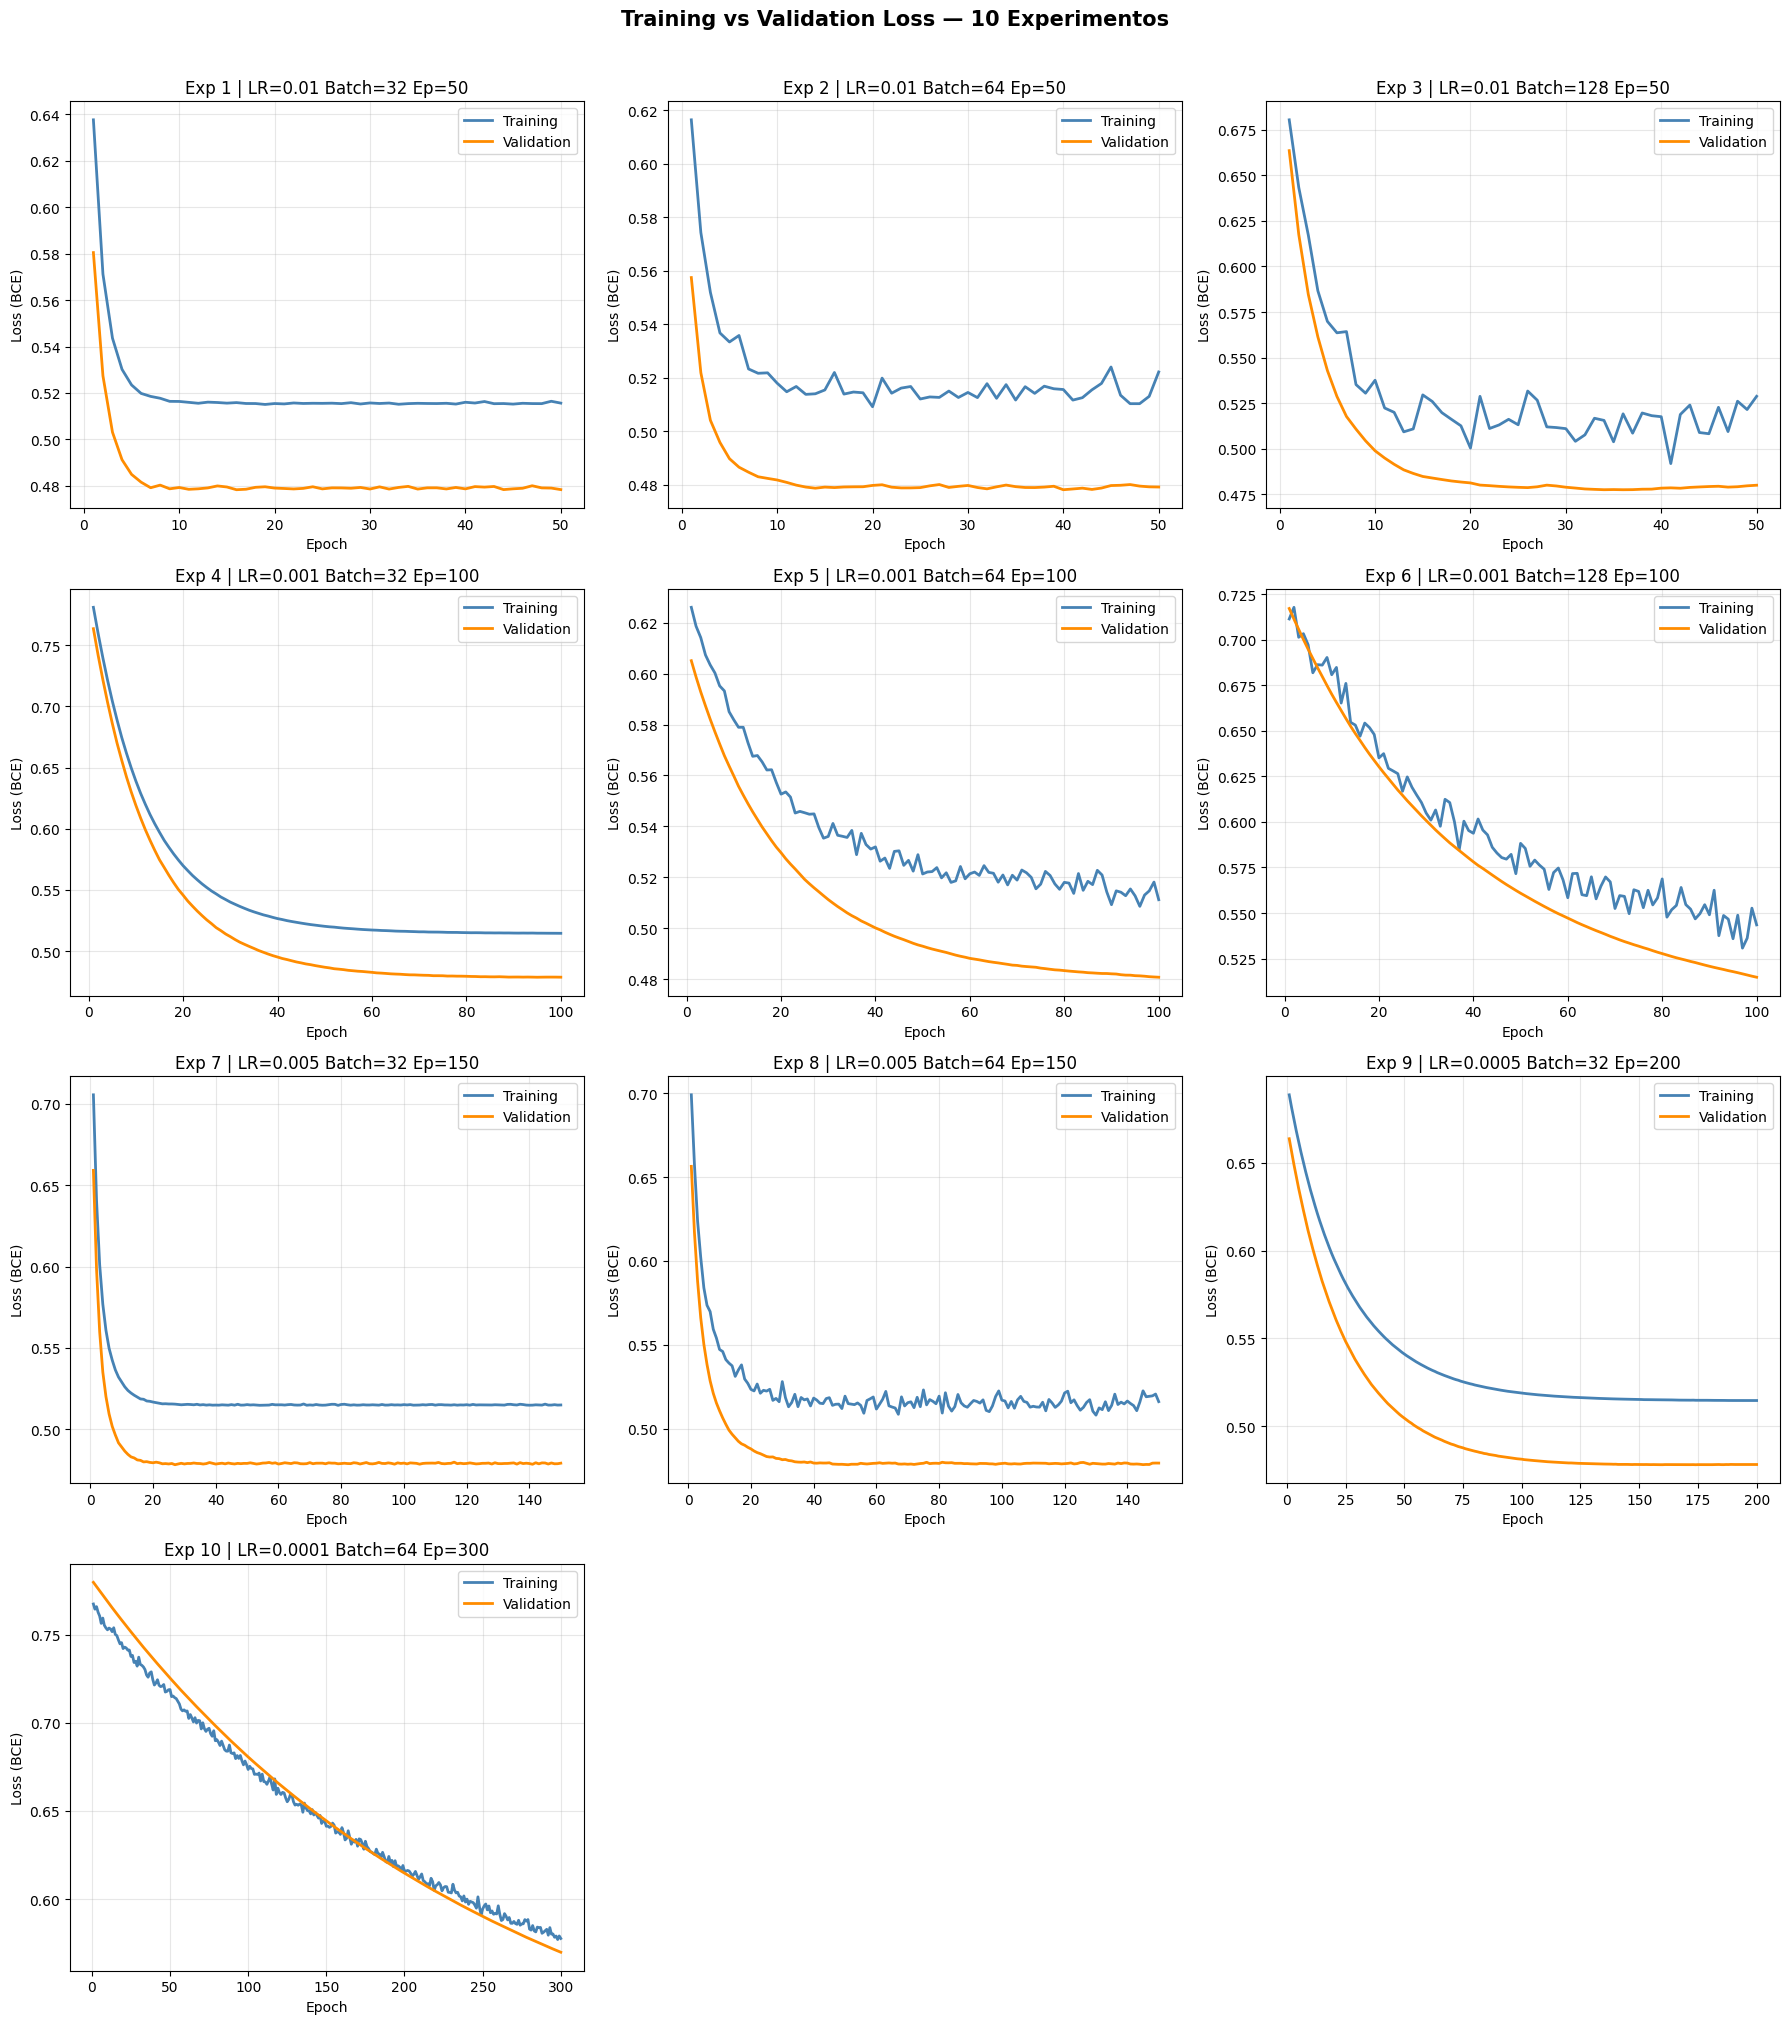

In [24]:
fig, axes = plt.subplots(4, 3, figsize=(18, 20), facecolor='white')
axes = axes.flatten()

for i, (hist, cfg) in enumerate(zip(histories, configs)):
    ax = axes[i]
    epochs_range = range(1, cfg['epochs'] + 1)
    ax.plot(epochs_range, hist['train_loss'], label='Training', color='steelblue', linewidth=2)
    ax.plot(epochs_range, hist['val_loss'],   label='Validation', color='darkorange', linewidth=2)
    ax.set_title(f'Exp {i+1} | LR={cfg["lr"]} Batch={cfg["batch_size"]} Ep={cfg["epochs"]}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss (BCE)')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Ocultar los ejes extras
for j in range(len(configs), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Training vs Validation Loss — 10 Experimentos', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Tabla Comparativa de Experimentos

In [25]:
results_df = pd.DataFrame(results)
print('Tabla comparativa de los 10 experimentos (validación):')
results_df.set_index('Exp')

Tabla comparativa de los 10 experimentos (validación):


,LR,Batch,Epochs,Train Loss,Val Loss,Overfitting,Accuracy,Precision,Recall,F1,AUC
Exp,,,,,,,,,,,
1,0.0100,32,50,0.5156,0.4784,No,0.7895,0.8202,0.7849,0.8022,0.8502
2,0.0100,64,50,0.5222,0.4792,No,0.7953,0.8295,0.7849,0.8066,0.8515
3,0.0100,128,50,0.5288,0.4800,No,0.7953,0.8222,0.7957,0.8087,0.8515
4,0.0010,32,100,0.5146,0.4787,No,0.7895,0.8132,0.7957,0.8043,0.8522
5,0.0010,64,100,0.5112,0.4807,No,0.7778,0.7957,0.7957,0.7957,0.8522
6,0.0010,128,100,0.5435,0.5148,No,0.7544,0.7629,0.7957,0.7789,0.8310
7,0.0050,32,150,0.5149,0.4791,No,0.7895,0.8132,0.7957,0.8043,0.8510
8,0.0050,64,150,0.5161,0.4795,No,0.7895,0.8132,0.7957,0.8043,0.8511
9,0.0005,32,200,0.5146,0.4782,No,0.7778,0.8022,0.7849,0.7935,0.8528


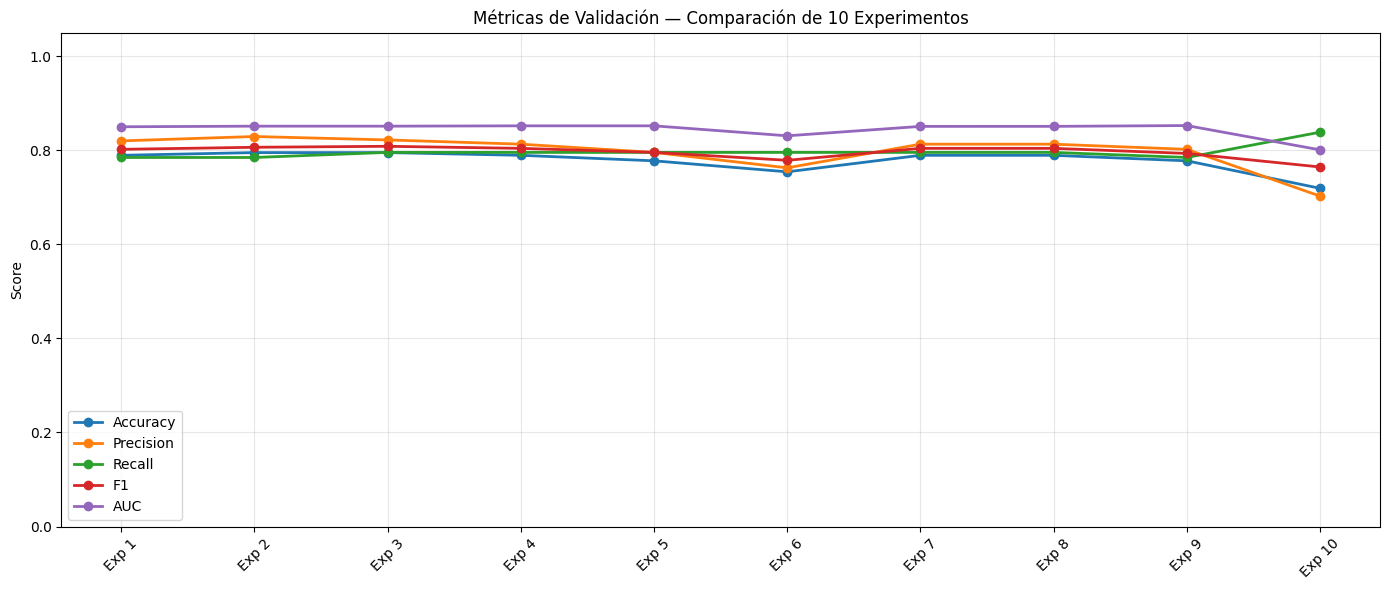

In [26]:
# Visualización de métricas comparativas
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
x = results_df['Exp']

fig, ax = plt.subplots(figsize=(14, 6))
for metric in metrics_to_plot:
    ax.plot(x, results_df[metric], marker='o', linewidth=2, label=metric)

ax.set_xticks(x)
ax.set_xticklabels([f'Exp {i}' for i in x], rotation=45)
ax.set_ylabel('Score')
ax.set_title('Métricas de Validación — Comparación de 10 Experimentos')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150)
plt.show()

## 11. Selección del Mejor Modelo y Evaluación en Test

In [27]:
# Seleccionar el modelo con mayor AUC en validación
best_idx = results_df['AUC'].idxmax()   # índice en el DataFrame (0-based)
best_exp = results_df.loc[best_idx, 'Exp']
best_cfg = configs[best_exp - 1]
best_model = models[best_exp - 1]

print(f'✅ Mejor modelo: Experimento {best_exp}')
print(f'   Configuración: {best_cfg}')
print(f'   AUC Validación: {results_df.loc[best_idx, "AUC"]:.4f}')
print(f'   F1  Validación: {results_df.loc[best_idx, "F1"]:.4f}')

✅ Mejor modelo: Experimento 9
   Configuración: {'lr': 0.0005, 'batch_size': 32, 'epochs': 200}
   AUC Validación: 0.8528
   F1  Validación: 0.7935


In [28]:
# Evaluación final en Test
test_metrics = compute_metrics(best_model, X_test, y_test)

print('\n=== Métricas en Test Set (Modelo Final) ===')
for k, v in test_metrics.items():
    print(f'  {k.capitalize():10s}: {v:.4f}')


=== Métricas en Test Set (Modelo Final) ===
  Accuracy  : 0.7442
  Precision : 0.7692
  Recall    : 0.7527
  F1        : 0.7609
  Auc       : 0.8282


## 11.5 Análisis de Pesos del Modelo Final

Los pesos aprendidos por `nn.Linear` corresponden directamente a los coeficientes de la regresión logística.
Un peso positivo alto indica que esa feature aumenta la probabilidad de BUENA; negativo, que la reduce.
Como las features están normalizadas (media 0, std 1), los pesos son comparables entre sí.

In [29]:
# --- Extraer pesos e interpretarlos ---
weights = best_model.linear.weight.detach().numpy().flatten()
bias    = best_model.linear.bias.detach().numpy()[0]

weights_df = pd.DataFrame({
    'Feature': selected,
    'Peso (w)': weights
}).sort_values('Peso (w)', ascending=False)

print(f'Bias (b): {bias:.4f}')
print('\nPesos aprendidos (ordenados de mayor a menor):')
print(weights_df.to_string(index=False))

print('\nInterpretación:')
for _, row in weights_df.iterrows():
    direccion = 'AUMENTA' if row['Peso (w)'] > 0 else 'REDUCE'
    print(f'  {row["Feature"]:25s} w={row["Peso (w)"]:+.4f}  → {direccion} prob. de calidad BUENA')

Bias (b): 0.2829

Pesos aprendidos (ordenados de mayor a menor):
             Feature  Peso (w)
             alcohol  0.951799
           sulphates  0.489479
             density  0.088484
           chlorides -0.179467
    volatile acidity -0.417355
total sulfur dioxide -0.439848

Interpretación:
  alcohol                   w=+0.9518  → AUMENTA prob. de calidad BUENA
  sulphates                 w=+0.4895  → AUMENTA prob. de calidad BUENA
  density                   w=+0.0885  → AUMENTA prob. de calidad BUENA
  chlorides                 w=-0.1795  → REDUCE prob. de calidad BUENA
  volatile acidity          w=-0.4174  → REDUCE prob. de calidad BUENA
  total sulfur dioxide      w=-0.4398  → REDUCE prob. de calidad BUENA


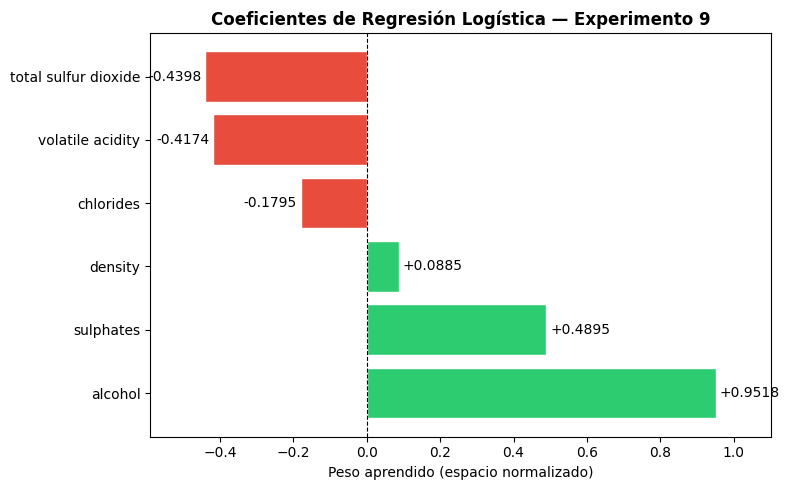


✅ Gráfica guardada como model_weights.png


In [30]:
# --- Visualización de pesos ---
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2ecc71' if w > 0 else '#e74c3c' for w in weights_df['Peso (w)']]
bars = ax.barh(weights_df['Feature'], weights_df['Peso (w)'], color=colors, edgecolor='white')

# Etiquetas con valor
for bar, val in zip(bars, weights_df['Peso (w)']):
    xpos = val + 0.01 if val >= 0 else val - 0.01
    ha   = 'left'    if val >= 0 else 'right'
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            f'{val:+.4f}', va='center', ha=ha, fontsize=10)

ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Peso aprendido (espacio normalizado)')
ax.set_title(f'Coeficientes de Regresión Logística — Experimento {best_exp}', fontweight='bold')
ax.set_xlim(min(weights_df['Peso (w)']) - 0.15, max(weights_df['Peso (w)']) + 0.15)
plt.tight_layout()
plt.savefig('model_weights.png', dpi=150)
plt.show()
print('\n✅ Gráfica guardada como model_weights.png')

In [31]:
# --- Análisis estadístico: ¿la diferencia entre Exp 4, 5 y 9 es significativa? ---
import scipy.stats as stats

# Los tres experimentos con AUC más cercano
top3 = results_df.nlargest(3, 'AUC')[['Exp', 'LR', 'Batch', 'Epochs', 'AUC']]
print('Top 3 experimentos por AUC en validación:')
print(top3.to_string(index=False))

# Intervalo de confianza aproximado para AUC (método de Hanley & McNeil)
# SE(AUC) ≈ sqrt(AUC*(1-AUC) / n_positivos)
n_pos_val = int(y_val.sum())
n_neg_val = len(y_val) - n_pos_val

print(f'\nConjunto de validación: {len(y_val)} muestras ({n_pos_val} positivos, {n_neg_val} negativos)')
print('\nIntervalos de confianza 95% para AUC (aprox. Hanley & McNeil):')

for _, row in top3.iterrows():
    auc = row['AUC']
    # Error estándar simplificado
    Q1  = auc / (2 - auc)
    Q2  = 2 * auc**2 / (1 + auc)
    se  = np.sqrt((auc*(1-auc) + (n_pos_val-1)*(Q1-auc**2) + (n_neg_val-1)*(Q2-auc**2)) /
                  (n_pos_val * n_neg_val))
    ci_lo = auc - 1.96 * se
    ci_hi = auc + 1.96 * se
    print(f'  Exp {int(row["Exp"]):2d}: AUC={auc:.4f}  IC95% = [{ci_lo:.4f}, {ci_hi:.4f}]  SE={se:.4f}')

print('\n→ Si los intervalos de confianza se solapan, la diferencia NO es estadísticamente significativa.')

Top 3 experimentos por AUC en validación:
 Exp     LR  Batch  Epochs    AUC
   9 0.0005     32     200 0.8528
   4 0.0010     32     100 0.8522
   5 0.0010     64     100 0.8522

Conjunto de validación: 171 muestras (93 positivos, 78 negativos)

Intervalos de confianza 95% para AUC (aprox. Hanley & McNeil):
  Exp  9: AUC=0.8528  IC95% = [0.7962, 0.9094]  SE=0.0289
  Exp  4: AUC=0.8522  IC95% = [0.7955, 0.9089]  SE=0.0290
  Exp  5: AUC=0.8522  IC95% = [0.7955, 0.9089]  SE=0.0290

→ Si los intervalos de confianza se solapan, la diferencia NO es estadísticamente significativa.


## 12. Matriz de Confusión (Test Set)

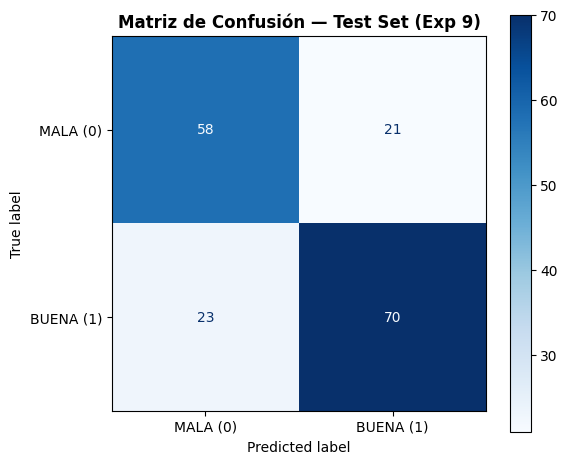


Verdaderos Negativos (TN): 58
Falsos Positivos    (FP): 21
Falsos Negativos    (FN): 23
Verdaderos Positivos(TP): 70


In [32]:
best_model.eval()
with torch.no_grad():
    X_test_t = torch.tensor(X_test, dtype=torch.float32)
    probs_test = best_model(X_test_t).numpy().flatten()

preds_test = (probs_test >= 0.5).astype(int)
cm = confusion_matrix(y_test, preds_test)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['MALA (0)', 'BUENA (1)'])
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title(f'Matriz de Confusión — Test Set (Exp {best_exp})', fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

print('\nVerdaderos Negativos (TN):', cm[0, 0])
print('Falsos Positivos    (FP):', cm[0, 1])
print('Falsos Negativos    (FN):', cm[1, 0])
print('Verdaderos Positivos(TP):', cm[1, 1])

## 13. Resumen Final

In [33]:
summary = pd.DataFrame({
    'Conjunto': ['Validación', 'Test'],
    'Accuracy':  [results_df.loc[best_idx, 'Accuracy'],  round(test_metrics['accuracy'], 4)],
    'Precision': [results_df.loc[best_idx, 'Precision'], round(test_metrics['precision'], 4)],
    'Recall':    [results_df.loc[best_idx, 'Recall'],    round(test_metrics['recall'], 4)],
    'F1':        [results_df.loc[best_idx, 'F1'],        round(test_metrics['f1'], 4)],
    'AUC':       [results_df.loc[best_idx, 'AUC'],       round(test_metrics['auc'], 4)],
})

print(f'=== Resumen — Experimento {best_exp} (Mejor Modelo) ===')
print(summary.to_string(index=False))

print('\n=== Imágenes generadas ===')
import os
imgs = ['target_distribution.png', 'histogramas.png', 'boxplots.png',
        'correlacion.png', 'outliers_count.png', 'outliers_before_after.png',
        'outliers_strategy_comparison.png',
        'feature_selection.png', 'scatter_features.png', 'model_weights.png',
        'training_curves.png', 'metrics_comparison.png', 'confusion_matrix.png']
for img in imgs:
    exists = '✅' if os.path.exists(img) else '❌'
    print(f'  {exists} {img}')

=== Resumen — Experimento 9 (Mejor Modelo) ===
  Conjunto  Accuracy  Precision  Recall     F1    AUC
Validación    0.7778     0.8022  0.7849 0.7935 0.8528
      Test    0.7442     0.7692  0.7527 0.7609 0.8282

=== Imágenes generadas ===
  ✅ target_distribution.png
  ✅ histogramas.png
  ✅ boxplots.png
  ✅ correlacion.png
  ✅ outliers_count.png
  ✅ outliers_before_after.png
  ✅ outliers_strategy_comparison.png
  ✅ feature_selection.png
  ✅ scatter_features.png
  ✅ model_weights.png
  ✅ training_curves.png
  ✅ metrics_comparison.png
  ✅ confusion_matrix.png
